In [1]:

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import sys
from pathlib import Path
from torchvision.datasets.utils import download_url
_old_sys_path = sys.path.copy()
try:
    project_root = Path.cwd().parent
    sys.path.insert(0, str(Path.cwd().resolve().parents[1]))
    from functions import graph_print_analysis as gp_tool
    from train_mnist_with_network import HBModel_MNIST as hbm

finally:
    sys.path = _old_sys_path


Project root added to sys.path: c:\Users\ASUS\Desktop\cone_dynamics


In [2]:
Output_Dir = Path.cwd().parent.parent / "experiments" / "MNIST_network"
num_epochs = 2
lr = 1e-2
if_decay = True
batch_sizes = {16, 32, 64, 128, 256, 512, 1024}
batch_size=256
steps = {200, 400, 800, 1200, 1600, 2000}
step=100
lrs={1e-4,1e-3, 1e-2, 1e-1}
decays={0, 1e-4, 1e-3, 1e-2}
if_regularize=True

In [3]:
##Test file
num_layers=5
model_name=f'mnist_hilbert_bs{batch_size}_lr{lr}_decay{if_decay}_reg{if_regularize}_layers{num_layers}_steps{500}'

testresult=hbm.train_mnist_with_hilbert(
    number_of_layers=num_layers,
    max_steps=1000,
    batch_size=512,
    lr=lr,
    if_regularize=if_regularize,
    if_decay=if_decay,
    save_path=Output_Dir/f"{model_name}_traj.pt")



In [4]:
param_traj=testresult['param_traj']

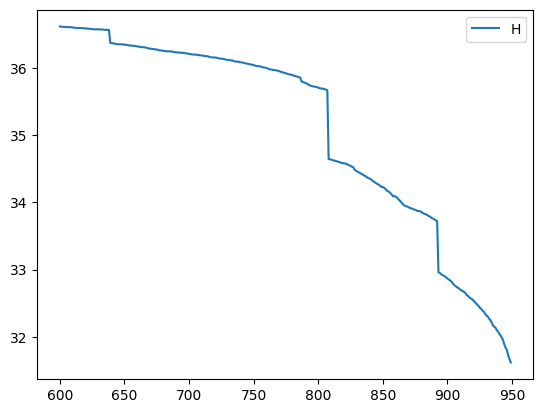

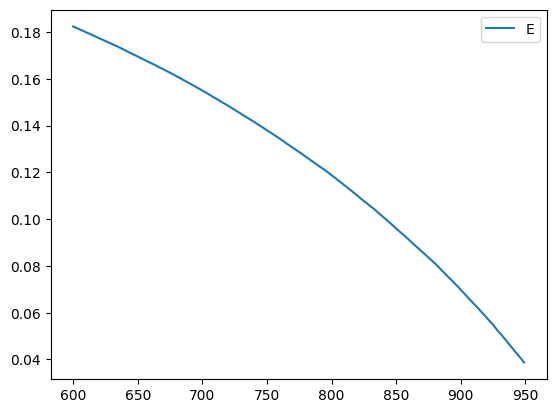

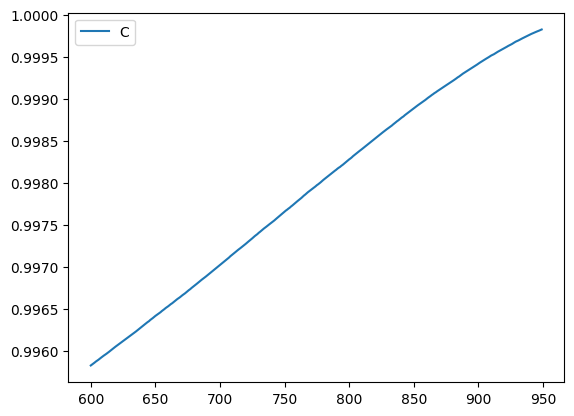

In [5]:
import matplotlib.pyplot as plt
import numpy as np
w_star=param_traj[-1]
H_to_finals=gp_tool.analysis_to_w_star(param_traj,param_traj[-1],if_writes=False,if_print=False)
H_to_final1=H_to_finals["hilbert_to_w_star_masked"]
l2_to_final=np.linalg.norm(np.array(param_traj)-param_traj[-1].cpu().numpy(),axis=1)
l2=l2_to_final[600:950]
Hn=H_to_final1[600:950]

plt.plot(range(600,950),Hn)
plt.legend("Hilbert")
plt.show()

plt.plot(range(600,950),l2)
plt.legend("Eucledean")
plt.show()
cos_to_final=param_traj@w_star.cpu().numpy()/(np.linalg.norm(np.array(param_traj),axis=1)*np.linalg.norm(w_star.cpu().numpy()))
cos=cos_to_final[600:950]
plt.plot(range(600,950),cos)
plt.legend("Cos")
plt.show()
# R = w_traj - w_star          # shape: (T+1, D)
# pca = PCA(n_components=1)
# pca.fit(R)

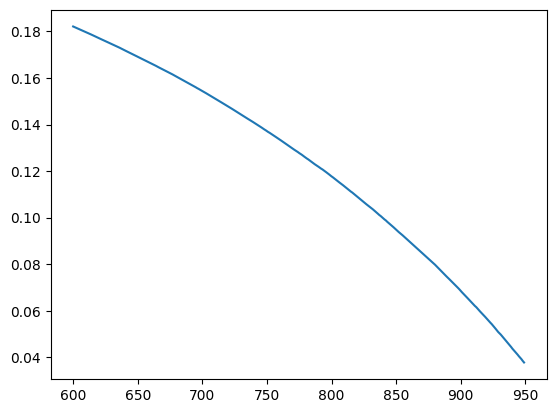

In [6]:
from sklearn.decomposition import PCA
trajectory = param_traj
w_traj = np.array(trajectory[600:950])    # shape: (T+1, D)
w_final = w_star.cpu().numpy()  # shape: (D,
R = w_traj - w_final          # shape: (T+1, D)
pca = PCA(n_components=1)
pca.fit(R)
v = pca.components_[0]       # 主方向，单位向量

a = R @ v                    # shape: (T+1,)
plt.plot(range(600,950),a)
plt.show()

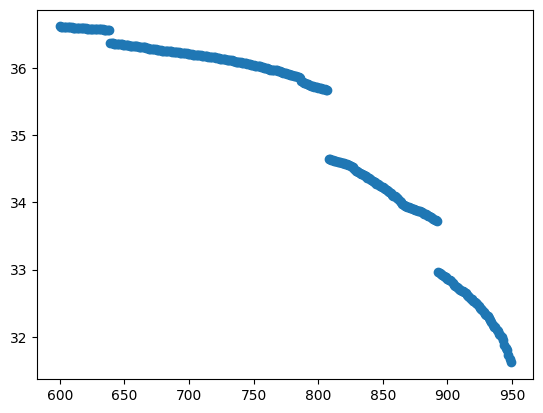

In [7]:
plt.scatter(range(600,950),Hn)


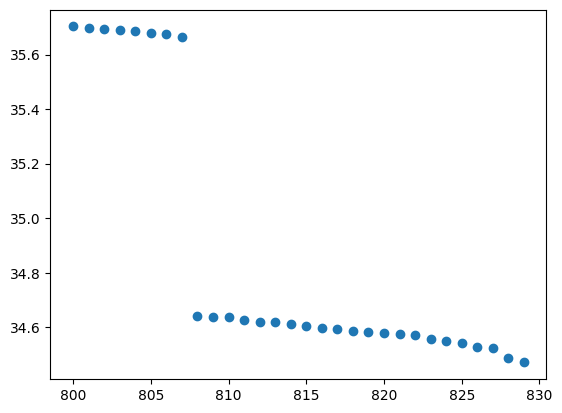

In [8]:
plt.scatter(range(800,830), H_to_final1[800:830])
special_traj=param_traj[800:830]
_old_sys_path = sys.path.copy()
try:
    project_root = Path.cwd().parent
    sys.path.insert(0, str(Path.cwd().resolve().parents[1]))
    from functions.Hilbert_computation import hilbert_computation as hbc
finally:
    sys.path = _old_sys_path

In [9]:
def hilbert_distance_1d(x, y, eps=1e-5):
    """
    x, y: 1D tensors, shape (d,)
    returns:
      hilbert_distance = log(max(x/y)) - log(min(x/y))
      max_index: argmax of x/y
      min_index: argmin of x/y
      (optional) max_ratio, min_ratio
    """
    x = x.clamp_min(eps)
    y = y.clamp_min(eps)

    ratio = x / y  # (d,)

    max_ratio, max_index = ratio.max(dim=0)  # scalar, scalar index
    min_ratio, min_index = ratio.min(dim=0)

    return {
        "hilbert_distance": (torch.log(max_ratio) - torch.log(min_ratio)),
        "max_index": int(max_index),
        "min_index": int(min_index),
        "max_ratio": max_ratio,
        "min_ratio": min_ratio,
    }


torch.Size([2560])
torch.Size([2560])
<class 'torch.Tensor'>


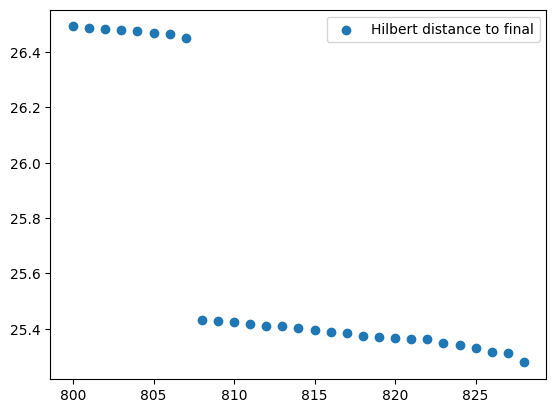

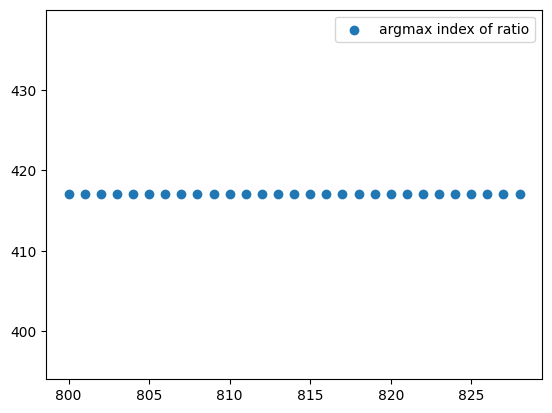

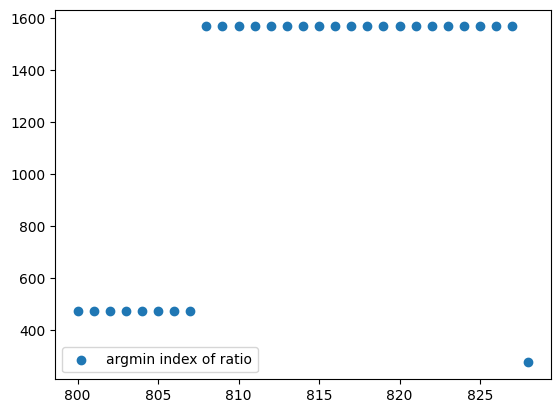

In [14]:
max_idx, min_idx, distances = [], [], []
print(trajectory[0].shape)
print(w_star.shape)
print(type(trajectory[0]))
for i in range(len(special_traj) - 1):
    res = hilbert_distance_1d(special_traj[i], w_star, 1e-8)
    max_idx.append(res["max_index"])
    min_idx.append(res["min_index"])
    distances.append(res["hilbert_distance"].item())

plt.scatter(range(800,800+len(distances)), distances, label="Hilbert distance to final")
plt.legend(); plt.show()

plt.scatter(range(800,800+len(max_idx)), max_idx, label="argmax index of ratio")
plt.legend(); plt.show()

plt.scatter(range(800,800+len(min_idx)), min_idx, label="argmin index of ratio")
plt.legend(); plt.show()


In [ ]:
print("argmin index of ratio",min_idx)
print("argmax index of ratio",max_idx)
print('Hilbert distances',[f"{d:.4f}" for d in distances])


argmin index of ratio [475, 475, 475, 475, 475, 475, 475, 475, 475, 1569, 1569, 1569, 1569, 1569, 1569, 1569, 1569, 1569, 1569, 1569, 1569, 1569, 1569, 1569, 1569, 1569, 1569, 1569, 275]
argmax index of ratio [417, 417, 417, 417, 417, 417, 417, 417, 417, 417, 417, 417, 417, 417, 417, 417, 417, 417, 417, 417, 417, 417, 417, 417, 417, 417, 417, 417, 417]
Hilbert distances ['12.6770', '12.6729', '12.6664', '12.6652', '12.6601', '12.6539', '12.6494', '12.6367', '12.2113', '11.6125', '11.6103', '11.6022', '11.5932', '11.5940', '11.5868', '11.5799', '11.5721', '11.5685', '11.5595', '11.5561', '11.5532', '11.5495', '11.5464', '11.5319', '11.5247', '11.5166', '11.5023', '11.4973', '11.4630']


In [ ]:
# for batch_size in batch_sizes:
#     for step in steps:
#             for lr in lrs:
#                 res=hbm.train_mnist_with_hilbert(
#                     batch_size=batch_size,
#                     lr=lr,
#                     # num_epochs=num_epochs,
#                     max_steps=step,
#                     if_regularize=if_regularize,
#                     if_decay=if_decay,)
#                 res=gp_tool.analysis(param_traj=res['param_traj'],output_log=res['output_log'],batch_size=batch_size,lr=res['lr'],steps=res['epochs_or_steps']
#                                     #  ,path='./huber_loss_results/'
#                                      )


In [ ]:
# HTF,HTB,HTI=analysis(param_traj=res['param_traj'],output_log=res['output_log'],batch_size=res['batch_size'],lr=res['lr'],num_epochs=res['epochs_or_steps'])

In [ ]:

# for res in results:
#     HTF=[]
#     HTB=[]
#     HTI=[]
#     hilbert_analysis_result=analysis(param_traj=res['param_traj'],output_log=res['output_log'],batch_size=res['batch_size'],lr=res['lr'],num_epochs=res['epochs_or_steps'])
#     HTF.append(hilbert_analysis_result["hilbert_to_finals"])
#     HTB.append(hilbert_analysis_result["hilbert_to_betweens"])
#     HTI.append(hilbert_analysis_result["hilbert_to_inits"])
#     torch.save({'HTF':HTF,'HTB':HTB,'HTI':HTI},f'Hilbert_bs{res["batch_size"]}_lr{res["lr"]}_{res["epochs_or_steps"]}.pt')
    

In [ ]:
# res=train_mnist_with_hilbert(batch_size=32,lr=lr,if_regularize=if_regularize,max_steps=steps,if_decay=if_decay
#                             #  ,loss_type="huber"
#                              )

In [ ]:
# res=gp_tool.analysis(param_traj=res['param_traj'],output_log=res['output_log'],batch_size=res['batch_size'],lr=res['lr'],num_epochs=res['epochs_or_steps']
#                     #  ,path='./huber_loss_results/'
#                      )
#     HTF=[]
#     HTB=[]
#     HTI=[]